# 03 Propensity model and persona tests

In [1]:
import sys
from pathlib import Path
ROOT = next(
    (parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (parent / 'src' / 'feature_engineering.py').is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)
from src.feature_engineering import load_raw, engineer_features

from src.propensity import train, predict
from src.recommender import recommend
res = train()
print('Test ROC-AUC:', round(res['auc'], 3))

Test ROC-AUC: 0.683


decile
10    0.36
9     0.46
8     0.74
7     0.65
6     0.58
5     0.79
4     1.03
3     1.16
2     1.63
1     2.60
Name: y, dtype: float64


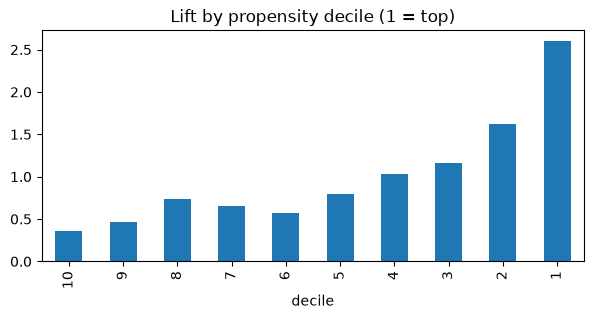

In [2]:
t = pd.DataFrame({'y': res['y_test'].values, 'p': res['p_test']})
t['decile'] = pd.qcut(t['p'].rank(method='first'), 10, labels=list(range(10, 0, -1)))
lift = (t.groupby('decile', observed=True)['y'].mean() / t['y'].mean()).sort_index()
print(lift.round(2))
lift.plot.bar(figsize=(7, 3), title='Lift by propensity decile (1 = top)')
plt.show()

In [3]:
personas = {
    'Young salaried, low balance': dict(age=24, job='services', balance=300, housing='no', loan='no', default='no'),
    'Mid-career manager, mortgage': dict(age=42, job='management', balance=6000, housing='yes', loan='no', default='no'),
    'Retired, high balance': dict(age=66, job='retired', balance=9000, housing='no', loan='no', default='no'),
    'Defaulter': dict(age=38, job='blue-collar', balance=-200, housing='yes', loan='yes', default='yes'),
}
for name, p in personas.items():
    o = recommend(p)
    print(f"{name}: {o['segment']} | {o['risk_profile']} | {o['primary'].split(' — ')[0]} | propensity {predict(p):.1%}")

Young salaried, low balance: Mass | Moderate | Term Life Insurance | propensity 19.9%
Mid-career manager, mortgage: HNI | Moderate | Term Life Insurance | propensity 8.2%
Retired, high balance: HNI | Conservative | Privilege Banking | propensity 45.8%
Defaulter: Mass | Conservative | Term Life Insurance | propensity 2.0%


**Honest note:** with call duration excluded, a customer-attribute-only model is a modest ranker (ROC-AUC well below 0.8), so use it to prioritise outreach, not to decide eligibility.